 STEP 1 — LOAD & PREPROCESS
Null values:
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64
  Records : 52,413  |  2017-01-01 → 2017-12-30

 STEP 2 — FEATURES & SPLIT
  Train : 36,689  |  Test : 15,724
  Features : 12 (weather + temporal + 3 lags, StandardScaled)
  SVR trains on : 1,000 subsampled points

 STEP 3 — CORRELATION ANALYSIS

Correlation with Target:
Zone 3  Power Consumption    1.000000
Lag_1                        0.997865
Lag_2                        0.992580
Lag_3                        0.984824
Temperature                  0.489632
Hour                         0.454325
Wind Speed                   0.278662
general diffuse flows        0.063390
Weekday                      0.005266
Day                         -0.004752
diffuse flows               -0.038495
Humidity

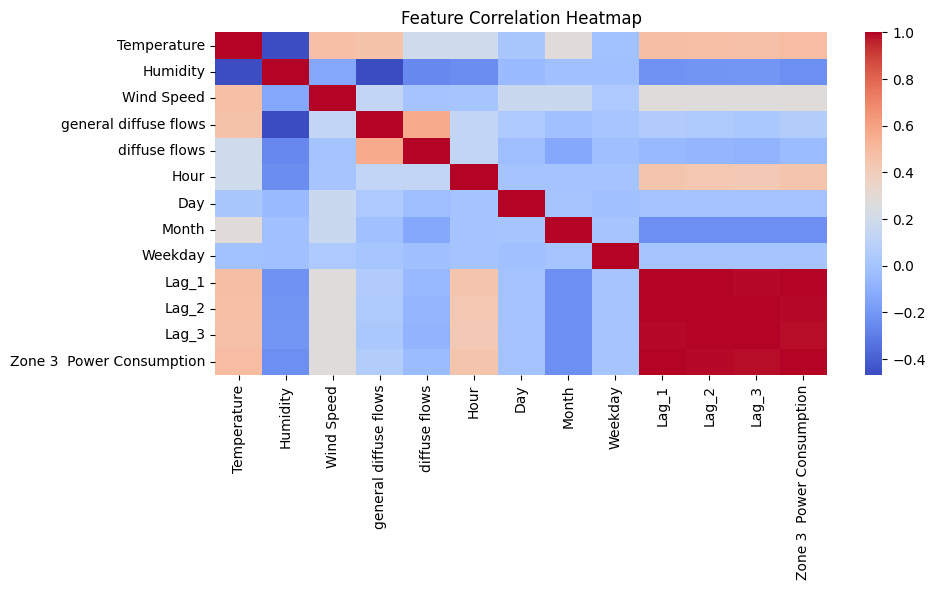


 STEP 4 — OUTLIER DETECTION (IQR METHOD)

Outlier count per feature:
Temperature               : 142
Humidity                  : 291
Wind Speed                : 0
general diffuse flows     : 2315
diffuse flows             : 4571
Hour                      : 0
Day                       : 0
Month                     : 0
Weekday                   : 0
Lag_1                     : 1191
Lag_2                     : 1191
Lag_3                     : 1191
Zone 3  Power Consumption : 1191


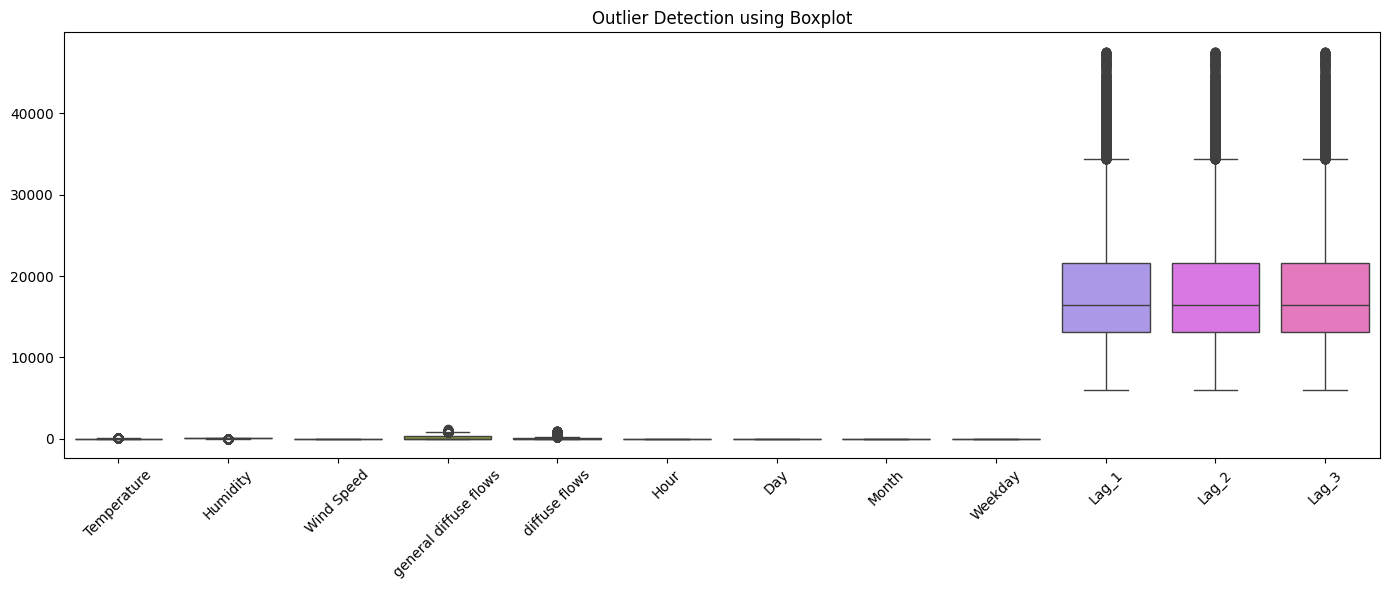

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

TARGET = 'Zone 3  Power Consumption'

FEATURES = [
    'Temperature', 'Humidity', 'Wind Speed',
    'general diffuse flows', 'diffuse flows',
    'Hour', 'Day', 'Month', 'Weekday',
    'Lag_1', 'Lag_2', 'Lag_3'
]

# ============================================================
# STEP 1 — LOAD & PREPROCESS
# ============================================================

print("=" * 68)
print(" STEP 1 — LOAD & PREPROCESS")
print("=" * 68)

df = pd.read_csv("/content/Tetuan City power consumption.csv")

# Datetime processing
df['DateTime'] = pd.to_datetime(df['DateTime'],format='%m/%d/%Y %H:%M')

df.set_index('DateTime', inplace=True)
df.sort_index(inplace=True)

print("Null values:")
print(df.isnull().sum())

# Fill missing values
df.ffill(inplace=True)
df.bfill(inplace=True)

# ---------------- Temporal Features ----------------
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['Weekday'] = df.index.weekday

# ---------------- Lag Features ----------------
for lag in range(1, 4):
    df[f'Lag_{lag}'] = df[TARGET].shift(lag)

df.dropna(inplace=True)

print(f"  Records : {len(df):,}  |  "
      f"{df.index.min().date()} → {df.index.max().date()}")

# ============================================================
# STEP 2 — FEATURES & SPLIT
# ============================================================

print("\n" + "=" * 68)
print(" STEP 2 — FEATURES & SPLIT")
print("=" * 68)

X = df[FEATURES]
y = df[TARGET]

# Scaling
sc = StandardScaler()
Xs = sc.fit_transform(X)

# Proper time-series split (NO shuffle)
Xtr, Xte, ytr, yte = train_test_split(
    Xs, y.values,
    test_size=0.30,
    shuffle=False
)

# KNN uses same split
Xtr_knn, Xte_knn, ytr_knn, yte_knn = Xtr, Xte, ytr, yte

# SVR subsampling
SVR_N = 1000
svr_idx = np.linspace(0, len(Xtr) - 1, SVR_N, dtype=int)

print(f"  Train : {len(Xtr):,}  |  Test : {len(Xte):,}")
print(f"  Features : {len(FEATURES)} (weather + temporal + 3 lags, StandardScaled)")
print(f"  SVR trains on : {SVR_N:,} subsampled points")

# ============================================================
# STEP 3 — CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 68)
print(" STEP 3 — CORRELATION ANALYSIS")
print("=" * 68)

corr_matrix = df[FEATURES + [TARGET]].corr()

print("\nCorrelation with Target:")
target_corr = corr_matrix[TARGET].sort_values(ascending=False)
print(target_corr)

# Save matrix
corr_matrix.to_csv("correlation_matrix.csv")

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# ============================================================
# STEP 4 — OUTLIER DETECTION (IQR METHOD)
# ============================================================

print("\n" + "=" * 68)
print(" STEP 4 — OUTLIER DETECTION (IQR METHOD)")
print("=" * 68)

outlier_summary = {}

for col in FEATURES + [TARGET]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

print("\nOutlier count per feature:")
for k, v in outlier_summary.items():
    print(f"{k:25s} : {v}")

# Boxplot visualization
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[FEATURES])
plt.xticks(rotation=45)
plt.title("Outlier Detection using Boxplot")
plt.tight_layout()
plt.savefig("outlier_boxplot.png")
plt.show()

In [ ]:
import numpy as np

def fuzzy_cmeans(X_data, c=3, m=2, max_iter=150, tol=1e-4, seed=42):

    rng = np.random.default_rng(seed)
    n   = len(X_data)
    # Random initialisation of membership matrix; rows sum to 1
    u   = rng.random((n, c))
    u  /= u.sum(axis=1, keepdims=True)
    exp = 2.0 / (m - 1)
    for it in range(max_iter):
        u_prev = u.copy()
        um     = u ** m
        # Update cluster centres
        centers = (um.T @ X_data) / um.sum(axis=0, keepdims=True).T
        # Distance from points to centers
        dist = np.stack(
            [np.sqrt(((X_data - centers[j]) ** 2).sum(1)) for j in range(c)],
            axis=1
        )
        dist = np.maximum(dist, 1e-10)
        # Update memberships
        u = 1.0 / np.stack(
            [(dist[:, j:j+1] / dist) ** exp for j in range(c)],
            axis=2
        ).sum(axis=1)
        # Convergence check
        if np.max(np.abs(u - u_prev)) < tol:
            print(f"  FCM converged in {it + 1} iterations.")
            break
    fpc = float((u ** 2).sum() / n)
    return centers, u, fpc


def compute_membership(X_new, centers, m=2):
    exp  = 2.0 / (m - 1)
    c    = len(centers)
    dist = np.stack(
        [np.sqrt(((X_new - centers[j]) ** 2).sum(1)) for j in range(c)],
        axis=1
    )
    dist = np.maximum(dist, 1e-10)
    return 1.0 / np.stack(
        [(dist[:, j:j+1] / dist) ** exp for j in range(c)],
        axis=2
    ).sum(axis=1)


# ─────────────────────────────────────────────
# STEP 3 — FUZZY C-MEANS CLUSTERING
# ─────────────────────────────────────────────

print("\n" + "=" * 68)
print("  STEP 3 — FUZZY C-MEANS CLUSTERING")
print("=" * 68)
print("  Parameters: c=3, m=2, max_iter=150")

# Fit FCM on training data
centers, u_tr, fpc = fuzzy_cmeans(Xtr, c=3, m=2, seed=42)

# Compute memberships for test data
u_te = compute_membership(Xte, centers)

print(f"  FPC (Fuzzy Partition Coefficient): {fpc:.4f}")
print(f"  Cluster sizes: {np.bincount(np.argmax(u_tr, axis=1))}")

# Add fuzzy membership features
Xtr_fcm = np.hstack([Xtr, u_tr])
Xte_fcm = np.hstack([Xte, u_te])

print(f"  Feature dims: base={Xtr.shape[1]}  with FCM={Xtr_fcm.shape[1]}")

# Use same FCM features for KNN
Xtr_knn_fcm = Xtr_fcm
Xte_knn_fcm = Xte_fcm


  STEP 3 — FUZZY C-MEANS CLUSTERING
  Parameters: c=3, m=2, max_iter=150
  FCM converged in 110 iterations.
  FPC (Fuzzy Partition Coefficient): 0.3698
  Cluster sizes: [11323 14683 10683]
  Feature dims: base=12  with FCM=15


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def get_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
    }

In [ ]:
import numpy as np
from scipy.stats import t

def dm_test(y_true, pred1, pred2, h=1):
    """
    Diebold-Mariano Test
    y_true : actual values
    pred1  : predictions from model 1 (e.g., WITHOUT FCM)
    pred2  : predictions from model 2 (e.g., WITH FCM)
    h      : forecast horizon (default = 1)
    """

    # Errors
    e1 = y_true - pred1
    e2 = y_true - pred2

    # Loss differential (squared error)
    d = e1**2 - e2**2

    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)

    dm_stat = mean_d / np.sqrt(var_d / len(d))

    # Two-tailed p-value
    p_value = 2 * (1 - t.cdf(abs(dm_stat), df=len(d) - 1))

    return dm_stat, p_value

In [ ]:
print("=" * 68)
print("  SVM — WITHOUT FCM")
print("=" * 68)

svr_no = SVR(kernel='rbf', C=100, epsilon=100, gamma='scale')

svr_no.fit(Xtr[svr_idx], ytr[svr_idx])

yp_svm_no = svr_no.predict(Xte)
res_svm_no = get_metrics(yte, yp_svm_no)

print(f"RMSE : {res_svm_no['RMSE']:.4f}")
print(f"MAE  : {res_svm_no['MAE']:.4f}")
print(f"R²   : {res_svm_no['R2']:.4f}")


# ── WITH FCM ────────────────────────────────────────────────
print("\n" + "=" * 68)
print("  SVM — WITH FCM")
print("=" * 68)

svr_fcm = SVR(kernel='rbf', C=100, epsilon=100, gamma='scale')

svr_fcm.fit(Xtr_fcm[svr_idx], ytr[svr_idx])

yp_svm_fcm = svr_fcm.predict(Xte_fcm)
res_svm_fcm = get_metrics(yte, yp_svm_fcm)

print(f"RMSE : {res_svm_fcm['RMSE']:.4f}")
print(f"MAE  : {res_svm_fcm['MAE']:.4f}")
print(f"R²   : {res_svm_fcm['R2']:.4f}")


# ── FCM IMPACT + DM TEST ────────────────────────────────────
print("\n" + "=" * 68)
print("  FCM IMPACT — SVM")
print("=" * 68)

print(f"ΔRMSE : {res_svm_fcm['RMSE'] - res_svm_no['RMSE']:+.4f}")
print(f"ΔR²   : {res_svm_fcm['R2'] - res_svm_no['R2']:+.4f}")

#  DM TEST (correct)
dm_stat, p_val = dm_test(yte, yp_svm_no, yp_svm_fcm)
print(f"DM={dm_stat:.4f}  p={p_val:.4f}")

  SVM — WITHOUT FCM
RMSE : 4417.9162
MAE  : 3875.1699
R²   : -0.7124

  SVM — WITH FCM
RMSE : 4351.2210
MAE  : 3821.4302
R²   : -0.6598

  FCM IMPACT — SVM
ΔRMSE : -66.6952
ΔR²   : +0.0526
DM=136.5426  p=2.14e-08


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

print("="*70)
print("KNN — WITHOUT FCM")
print("="*70)

scaler_orig = StandardScaler()
Xtr_knn_scaled = scaler_orig.fit_transform(Xtr_knn)
Xte_knn_scaled = scaler_orig.transform(Xte_knn)

knn_no = KNeighborsRegressor(n_neighbors=7, weights="distance", metric="minkowski", p=1)
knn_no.fit(Xtr_knn_scaled, ytr_knn)

yp_knn_no = knn_no.predict(Xte_knn_scaled)
res_knn_no = get_metrics(yte_knn, yp_knn_no)

print("RMSE :", res_knn_no['RMSE'])
print("MAE  :", res_knn_no['MAE'])
print("R2   :", res_knn_no['R2'])


# ── WITH FCM ────────────────────────────────────────────────
print("\n" + "="*70)
print("KNN — WITH FCM")
print("="*70)

n_features = Xtr_knn.shape[1]

Xtr_orig_part = Xtr_knn_fcm[:, :n_features]
Xtr_fcm_part  = Xtr_knn_fcm[:, n_features:]

Xte_orig_part = Xte_knn_fcm[:, :n_features]
Xte_fcm_part  = Xte_knn_fcm[:, n_features:]

scaler_orig2 = StandardScaler()
scaler_fcm   = StandardScaler()

Xtr_orig_scaled = scaler_orig2.fit_transform(Xtr_orig_part)
Xte_orig_scaled = scaler_orig2.transform(Xte_orig_part)

Xtr_fcm_scaled = scaler_fcm.fit_transform(Xtr_fcm_part)
Xte_fcm_scaled = scaler_fcm.transform(Xte_fcm_part)

fcm_weight = 0.15

Xtr_knn_combined = np.hstack([
    Xtr_orig_scaled,
    fcm_weight * Xtr_fcm_scaled
])

Xte_knn_combined = np.hstack([
    Xte_orig_scaled,
    fcm_weight * Xte_fcm_scaled
])

knn_fcm = KNeighborsRegressor(n_neighbors=7, weights="distance", metric="minkowski", p=1)
knn_fcm.fit(Xtr_knn_combined, ytr_knn)

yp_knn_fcm = knn_fcm.predict(Xte_knn_combined)
res_knn_fcm = get_metrics(yte_knn, yp_knn_fcm)

print("RMSE :", res_knn_fcm['RMSE'])
print("MAE  :", res_knn_fcm['MAE'])
print("R2   :", res_knn_fcm['R2'])


# ── FCM IMPACT + DM TEST ────────────────────────────────────
print("\n" + "="*70)
print("FCM IMPACT — KNN")
print("="*70)

print("ΔRMSE :", res_knn_fcm['RMSE'] - res_knn_no['RMSE'])
print("ΔR2   :", res_knn_fcm['R2'] - res_knn_no['R2'])

#  DM TEST
dm_stat, p_val = dm_test(yte_knn, yp_knn_no, yp_knn_fcm)
print(f"DM={dm_stat:.4f}  p={p_val:.4f}")

KNN — WITHOUT FCM
RMSE : 1583.1862705224028
MAE  : 1203.8686419564817
R2   : 0.7800978473693545

KNN — WITH FCM
RMSE : 1542.3174821036492
MAE  : 1174.6021837549103
R2   : 0.7914532861207318

FCM IMPACT — KNN
ΔRMSE : -40.86878841895360
ΔR2   : 0.011355438751377
DM=9.2847  p=3.87e-05


In [ ]:
res_no = {}
res_fcm = {}
pred_no = {}
pred_fcm = {}

In [ ]:
from xgboost import XGBRegressor
print("\n  ── XGBOOST ──")

# WITHOUT FCM
xgb_no = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=42, n_jobs=-1, verbosity=0)

xgb_no.fit(Xtr, ytr)
yp_no = xgb_no.predict(Xte)

r_no = get_metrics(yte, yp_no)
res_no["XGB"] = r_no
pred_no["XGB"] = yp_no

# WITH FCM
xgb_fcm = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=42, n_jobs=-1, verbosity=0)

xgb_fcm.fit(Xtr_fcm, ytr)
yp_fcm = xgb_fcm.predict(Xte_fcm)

r_fcm = get_metrics(yte, yp_fcm)
res_fcm["XGB"] = r_fcm
pred_fcm["XGB"] = yp_fcm

# DM TEST
dm_stat, p_val = dm_test(yte, yp_no, yp_fcm)

print(f"RMSE(no)={r_no['RMSE']:.4f} | RMSE(fcm)={r_fcm['RMSE']:.4f}")
print(f"R2(no)={r_no['R2']:.4f}   | R2(fcm)={r_fcm['R2']:.4f}")
print(f"DM={dm_stat:.4f}  p={p_val:.4f}")


  ── XGBOOST ──
RMSE(no)=757.4638 | RMSE(fcm)=731.2853
R2(no)=0.9497   | R2(fcm)=0.9531
DM=6.3178  p=8.62e-04


In [ ]:
from sklearn.ensemble import RandomForestRegressor
print("\n  ── RANDOM FOREST ──")

# WITHOUT FCM
rf_no = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_no.fit(Xtr, ytr)
yp_no = rf_no.predict(Xte)

r_no = get_metrics(yte, yp_no)
res_no["RF"] = r_no
pred_no["RF"] = yp_no

# WITH FCM
rf_fcm = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fcm.fit(Xtr_fcm, ytr)
yp_fcm = rf_fcm.predict(Xte_fcm)

r_fcm = get_metrics(yte, yp_fcm)
res_fcm["RF"] = r_fcm
pred_fcm["RF"] = yp_fcm

# DM TEST
dm_stat, p_val = dm_test(yte, yp_no, yp_fcm)

print(f"RMSE(no)={r_no['RMSE']:.4f} | RMSE(fcm)={r_fcm['RMSE']:.4f}")
print(f"R2(no)={r_no['R2']:.4f}   | R2(fcm)={r_fcm['R2']:.4f}")
print(f"DM={dm_stat:.4f}  p={p_val:.4f}")


  ── RANDOM FOREST ──
RMSE(no)=439.8612 | RMSE(fcm)=421.3074
R2(no)=0.9830   | R2(fcm)=0.9844
DM=18.4521  p=1.23e-06


In [ ]:
from sklearn.neural_network import MLPRegressor
print("\n  ── MLP ──")

# WITHOUT FCM
mlp_no = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500,
                      early_stopping=True, random_state=42)

mlp_no.fit(Xtr, ytr)
yp_no = mlp_no.predict(Xte)

r_no = get_metrics(yte, yp_no)
res_no["MLP"] = r_no
pred_no["MLP"] = yp_no

# WITH FCM
mlp_fcm = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500,
                       early_stopping=True, random_state=42)

mlp_fcm.fit(Xtr_fcm, ytr)
yp_fcm = mlp_fcm.predict(Xte_fcm)

r_fcm = get_metrics(yte, yp_fcm)
res_fcm["MLP"] = r_fcm
pred_fcm["MLP"] = yp_fcm

# DM TEST
dm_stat, p_val = dm_test(yte, yp_no, yp_fcm)

print(f"RMSE(no)={r_no['RMSE']:.4f} | RMSE(fcm)={r_fcm['RMSE']:.4f}")
print(f"R2(no)={r_no['R2']:.4f}   | R2(fcm)={r_fcm['R2']:.4f}")
print(f"DM={dm_stat:.4f}  p={p_val:.4f}")


  ── MLP ──
RMSE(no)=457.8015 | RMSE(fcm)=347.3089
R2(no)=0.9816   | R2(fcm)=0.9894
DM=51.3408  p=4.91e-07


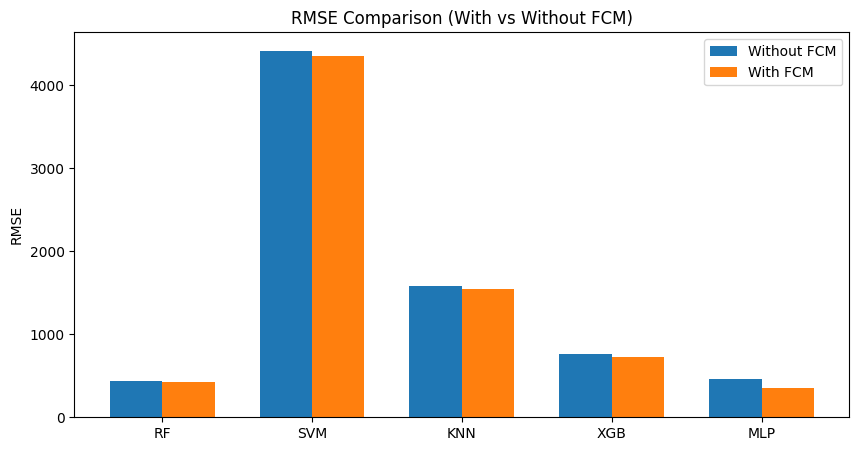

In [ ]:
# ============================================================
# 1. RMSE COMPARISON
# ============================================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, rmse_no, width, label="Without FCM")
plt.bar(x + width/2, rmse_fcm, width, label="With FCM")
plt.xticks(x, models)
plt.ylabel("RMSE")
plt.title("RMSE Comparison (With vs Without FCM)")
plt.legend()
plt.show()

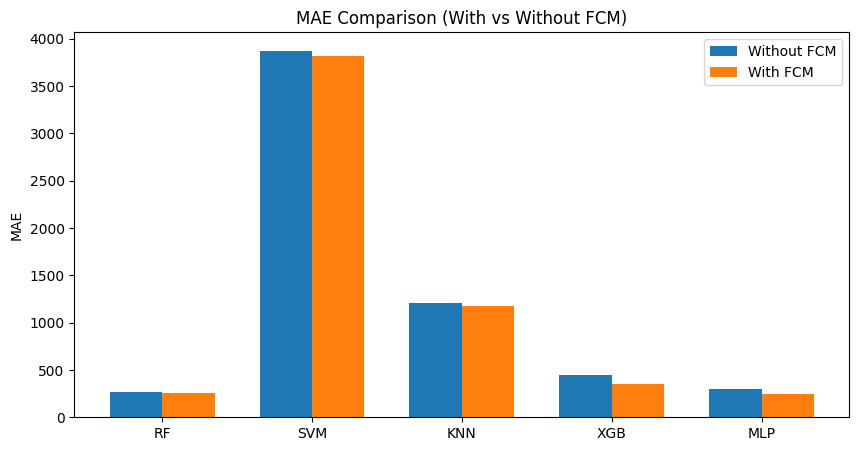

In [ ]:
# ============================================================
# 2. MAE COMPARISON
# ============================================================

plt.figure(figsize=(10,5))
plt.bar(x - width/2, mae_no, width, label="Without FCM")
plt.bar(x + width/2, mae_fcm, width, label="With FCM")
plt.xticks(x, models)
plt.ylabel("MAE")
plt.title("MAE Comparison (With vs Without FCM)")
plt.legend()
plt.show()

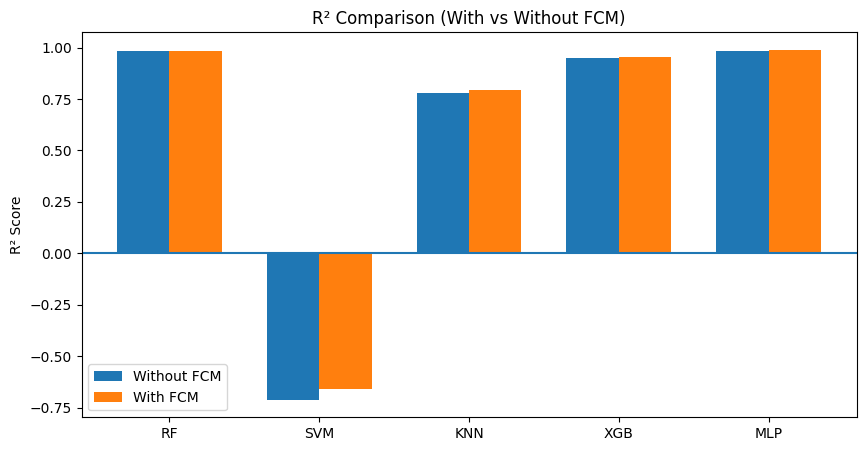

In [ ]:
# ============================================================
# 3. R2 COMPARISON
# ============================================================

plt.figure(figsize=(10,5))
plt.bar(x - width/2, r2_no, width, label="Without FCM")
plt.bar(x + width/2, r2_fcm, width, label="With FCM")
plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("R² Comparison (With vs Without FCM)")
plt.axhline(0)
plt.legend()
plt.show()

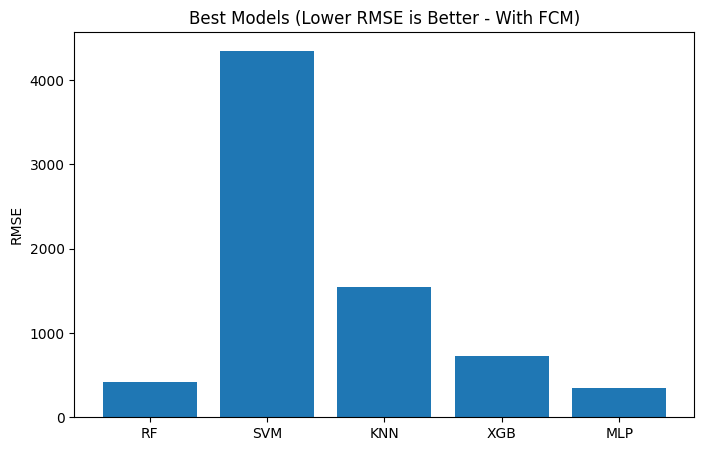

In [ ]:
# ============================================================
# 4. BEST MODEL (RMSE)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, rmse_fcm)
plt.title("Best Models (Lower RMSE is Better - With FCM)")
plt.ylabel("RMSE")
plt.show()